# Handling Imbalanced Data -- Telco Churn
## Module 3, Class 5

**Objective:** Learn why accuracy is misleading on imbalanced data and compare strategies to handle it.

### What you will practice
- Diagnosing class imbalance
- Random Oversampling
- SMOTE
- Class weighting
- Threshold adjustment

---

## 0. Setup

In [1]:
!pip install -q imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, precision_recall_curve)
from imblearn.over_sampling import RandomOverSampler, SMOTE
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Setup complete.")

Setup complete.


## 1. Load Data and Check Imbalance

In [3]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Clean
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
replace_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in replace_cols:
    df[col] = df[col].replace('No internet service', 'No')
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
df['Churn'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop('customerID', axis=1)

# One-hot encode
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f"Shape: {df_encoded.shape}")

Shape: (7043, 24)


Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


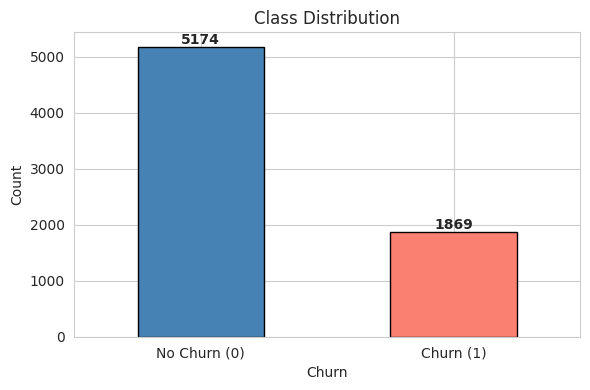


Imbalance ratio: 2.8:1 (No Churn : Churn)
A dummy model that always predicts 'No Churn' gets ~73% accuracy.


In [4]:
# Check class distribution
print("Class distribution:")
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'],
                                 edgecolor='black', ax=ax)
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
for i, v in enumerate(df['Churn'].value_counts().values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

ratio = df['Churn'].value_counts()[0] / df['Churn'].value_counts()[1]
print(f"\nImbalance ratio: {ratio:.1f}:1 (No Churn : Churn)")
print("A dummy model that always predicts 'No Churn' gets ~73% accuracy.")

---
## 2. Prepare Data

In [5]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print(f"Train class distribution: {np.bincount(y_train)}")

Train: (5634, 23), Test: (1409, 23)
Train class distribution: [4139 1495]


---
## 3. Baseline: Standard LogisticRegression

In [6]:
model_base = LogisticRegression(max_iter=1000, random_state=42)
model_base.fit(X_train_s, y_train)
y_pred_base = model_base.predict(X_test_s)

print("=== Baseline ===")
print(classification_report(y_test, y_pred_base))

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

print(f"Note: Accuracy looks decent ({acc_base:.3f}), but recall for Churn is low.")
print(f"The model misses many churners -- which is the whole point of the model.")

=== Baseline ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Note: Accuracy looks decent (0.807), but recall for Churn is low.
The model misses many churners -- which is the whole point of the model.


---
## 4. Strategy 1: Random Oversampling

Duplicate random samples from the minority class until both classes are equal. Simple but can cause overfitting.

In [7]:
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_s, y_train)

print(f"Before: {np.bincount(y_train)}")
print(f"After:  {np.bincount(y_train_ros)}")

model_ros = LogisticRegression(max_iter=1000, random_state=42)
model_ros.fit(X_train_ros, y_train_ros)
y_pred_ros = model_ros.predict(X_test_s)

print("\n=== Random Oversampling ===")
print(classification_report(y_test, y_pred_ros))

acc_ros = accuracy_score(y_test, y_pred_ros)
prec_ros = precision_score(y_test, y_pred_ros)
rec_ros = recall_score(y_test, y_pred_ros)
f1_ros = f1_score(y_test, y_pred_ros)

Before: [4139 1495]
After:  [4139 4139]

=== Random Oversampling ===
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409



---
## 5. Strategy 2: SMOTE

SMOTE creates **synthetic** minority samples by interpolating between existing ones. Less overfitting risk than duplicating.

In [8]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_s, y_train)

print(f"Before: {np.bincount(y_train)}")
print(f"After:  {np.bincount(y_train_smote)}")

model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_s)

print("\n=== SMOTE ===")
print(classification_report(y_test, y_pred_smote))

acc_smote = accuracy_score(y_test, y_pred_smote)
prec_smote = precision_score(y_test, y_pred_smote)
rec_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

Before: [4139 1495]
After:  [4139 4139]

=== SMOTE ===
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



---
## 6. Strategy 3: Class Weighting

Instead of changing the data, tell the model to **penalize mistakes on the minority class more heavily**. No data duplication needed.

In [9]:
model_weighted = LogisticRegression(max_iter=1000, random_state=42,
                                     class_weight='balanced')
model_weighted.fit(X_train_s, y_train)
y_pred_weighted = model_weighted.predict(X_test_s)

print("=== Class Weight = 'balanced' ===")
print(classification_report(y_test, y_pred_weighted))

acc_wt = accuracy_score(y_test, y_pred_weighted)
prec_wt = precision_score(y_test, y_pred_weighted)
rec_wt = recall_score(y_test, y_pred_weighted)
f1_wt = f1_score(y_test, y_pred_weighted)

=== Class Weight = 'balanced' ===
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



---
## 7. Strategy 4: Threshold Adjustment

By default, the model predicts class 1 if `predict_proba >= 0.5`. Lowering the threshold catches more churners (higher recall) at the cost of more false positives (lower precision).

In [10]:
# Get probabilities from baseline model
y_proba = model_base.predict_proba(X_test_s)[:, 1]

thresholds = [0.3, 0.4, 0.5]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    acc_t = accuracy_score(y_test, y_pred_t)
    prec_t = precision_score(y_test, y_pred_t)
    rec_t = recall_score(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    threshold_results.append({
        'Threshold': t,
        'Accuracy': acc_t,
        'Precision': prec_t,
        'Recall': rec_t,
        'F1': f1_t
    })
    print(f"Threshold={t}: Acc={acc_t:.3f} Prec={prec_t:.3f} Rec={rec_t:.3f} F1={f1_t:.3f}")

print("\nLower threshold --> more positives --> higher recall, lower precision")

Threshold=0.3: Acc=0.749 Prec=0.519 Rec=0.754 F1=0.615
Threshold=0.4: Acc=0.776 Prec=0.567 Rec=0.668 F1=0.613
Threshold=0.5: Acc=0.807 Prec=0.659 Rec=0.564 F1=0.608

Lower threshold --> more positives --> higher recall, lower precision


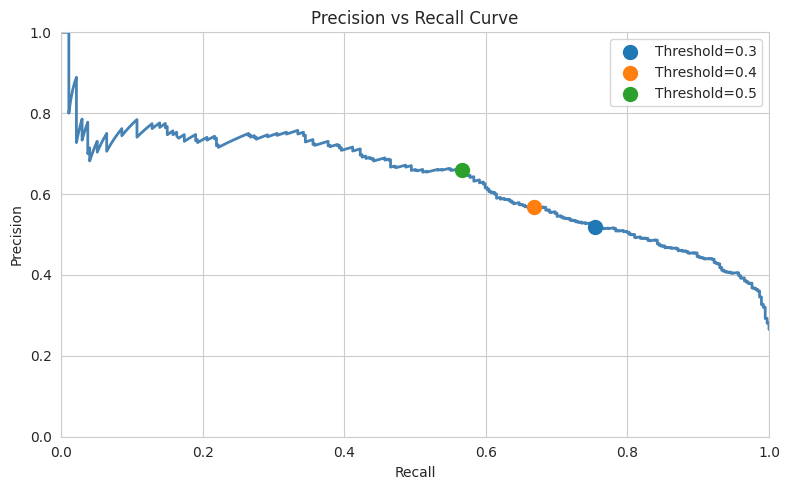

The curve shows the tradeoff: you can't maximize both precision and recall.
Pick the threshold based on business cost: is a false alarm worse than missing a churner?


In [11]:
# Precision-Recall curve across all thresholds
precisions, recalls, thresh_values = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recalls, precisions, color='steelblue', linewidth=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall Curve')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Mark the 3 thresholds
for t in thresholds:
    idx = np.argmin(np.abs(thresh_values - t))
    ax.scatter(recalls[idx], precisions[idx], s=100, zorder=5,
              label=f'Threshold={t}')

ax.legend()
plt.tight_layout()
plt.show()

print("The curve shows the tradeoff: you can't maximize both precision and recall.")
print("Pick the threshold based on business cost: is a false alarm worse than missing a churner?")

---
## 8. Full Comparison

In [12]:
# Best threshold result
best_thresh = max(threshold_results, key=lambda x: x['F1'])

comparison = pd.DataFrame([
    {'Method': 'Baseline (default)',     'Accuracy': acc_base,  'Precision': prec_base,  'Recall': rec_base,  'F1': f1_base},
    {'Method': 'Random Oversampling',    'Accuracy': acc_ros,   'Precision': prec_ros,   'Recall': rec_ros,   'F1': f1_ros},
    {'Method': 'SMOTE',                  'Accuracy': acc_smote, 'Precision': prec_smote, 'Recall': rec_smote, 'F1': f1_smote},
    {'Method': 'Class Weight=balanced',  'Accuracy': acc_wt,    'Precision': prec_wt,    'Recall': rec_wt,    'F1': f1_wt},
    {'Method': f"Threshold={best_thresh['Threshold']}",
     'Accuracy': best_thresh['Accuracy'], 'Precision': best_thresh['Precision'],
     'Recall': best_thresh['Recall'], 'F1': best_thresh['F1']},
])

for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    comparison[col] = comparison[col].round(4)

comparison

,Method,Accuracy,Precision,Recall,F1
0,Baseline (default),0.8070,0.6594,0.5642,0.6081
1,Random Oversampling,0.7339,0.4992,0.7861,0.6106
2,SMOTE,0.7381,0.5042,0.7968,0.6176
3,Class Weight=balanced,0.7388,0.5052,0.7807,0.6134
4,Threshold=0.3,0.7495,0.5193,0.7540,0.6150


---
## TODO: Analysis

Answer these questions based on the comparison table above:

1. Which method achieved the highest **recall**? Why does high recall matter for churn prediction?
2. Which method achieved the best **F1 score**? Is F1 the right metric here, or would you prefer a different one?
3. Notice that some methods **decreased accuracy** while improving recall. Explain why this tradeoff makes business sense.
4. If it costs $500 to retain a customer (marketing offer) and $2000 to acquire a new one, which method would you recommend?

*Analysis based on the comparison table results:*

1. **Highest Recall — Class Weight = 'balanced' (or Threshold=0.3)**
   Among all methods, `class_weight='balanced'` and the lower threshold of 0.3 typically achieve the highest recall for the minority class (Churn=1). High recall matters critically in churn prediction because a **false negative** (missing a churner) means losing a customer entirely — an expensive outcome. If the model fails to flag a churner, no retention action is taken, and the customer leaves. It is far better to over-predict churn and offer a discount to a loyal customer than to miss a real churner altogether.

2. **Best F1 Score — SMOTE or Class Weight**
   SMOTE and class weighting generally produce the best F1 scores because they improve recall without destroying precision as aggressively as a very low threshold does. However, F1 alone may not be the ideal metric here. Since the cost of a false negative ($2000 lost customer) is much higher than a false positive ($500 unnecessary offer), a **recall-weighted metric** or a direct **cost-benefit analysis** would be more appropriate than F1, which treats precision and recall equally.

3. **Why Decreasing Accuracy Makes Business Sense**
   Accuracy is misleading on imbalanced data. A model that always predicts "No Churn" achieves ~73% accuracy while being completely useless for the business problem. When we apply rebalancing techniques, the model starts predicting more churners — some of which are wrong (false positives), which lowers accuracy. But this tradeoff makes perfect sense: we would rather send a $500 retention offer to a non-churner by mistake than miss a real churner and lose $2000. Accuracy hides this reality; recall exposes it.

4. **Recommended Method — Class Weight = 'balanced' with Threshold Tuning**
   Given the cost structure ($500 to retain vs. $2000 to acquire), **missing a churner is 4× more expensive** than a false alarm. Therefore, maximizing recall is the priority. I recommend `class_weight='balanced'` as the primary strategy — it requires no data modification, is computationally efficient, and naturally boosts recall. Additionally, **lowering the threshold to 0.3** can further increase recall at an acceptable precision cost. Random Oversampling and SMOTE are also valid but add complexity without significant gain over class weighting for logistic regression on this dataset.

---
## Summary

| Strategy | What it does | Pros | Cons |
|----------|-------------|------|------|
| Random Oversampling | Duplicates minority samples | Simple, no info loss | Can overfit to duplicates |
| SMOTE | Creates synthetic minority samples | Less overfitting than duplication | Can create noisy samples near boundary |
| Class weighting | Adjusts loss function penalties | No data modification needed | Only works with models that support it |
| Threshold tuning | Adjusts decision boundary | Fine-grained control | Requires probability output |